In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression


In [38]:
df=pd.read_pickle("../Data/countries_clean.plk")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   192 non-null    object 
 1   Capital                   192 non-null    object 
 2   Constitutional_Form       192 non-null    object 
 3   Religion                  192 non-null    object 
 4   Democracy_Score           192 non-null    float64
 5   Democracy_Classification  192 non-null    object 
 6   Development_Status        192 non-null    object 
 7   Latitude                  192 non-null    float64
 8   Longitude                 192 non-null    float64
 9   Area                      192 non-null    int64  
 10  Population                192 non-null    int64  
 11  GDP                       192 non-null    int64  
 12  %Agriculture              192 non-null    float64
 13  GDP_CAPITA                192 non-null    float64
 14  Life_exp  

In [39]:
df

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Development_Status,Latitude,Longitude,Area,...,lon_pos,Equatorial,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category
0,Afghanistan,Kabul,Islamic Republic (Provisional),Islam,0.25,Authoritarian,Developing,34.5328,69.1658,652230,...,North,No,Yes,Asia,63.1,South Asia,Yes,29286,Low,Low
1,Albania,Tirana,Parliamentary Republic,Islam,6.20,Flawed Democracy,Developing,41.3289,19.8178,28748,...,North,No,Yes,Europe,96.6,Central Europe,No,531448,Upper-Middle,High
2,Algeria,Algiers,Presidential Republic,Islam,3.55,Authoritarian,Developing,36.7764,3.0586,2381741,...,North,No,No,Africa,18.9,North Africa,No,71371,Lower-Middle,High
3,Andorra,Andorra la Vella,Parliamentary Co-Principality,Christianity,8.61,Full Democracy,Developed,42.5000,1.5200,468,...,North,No,Yes,Europe,170.6,Western Europe,Yes,6739440,High,High
4,Angola,Luanda,Presidential Republic,Christianity,4.05,Hybrid Regime,Developing,-8.8383,13.2344,1246700,...,South,Yes,Yes,Africa,28.5,East Africa,No,75909,Lower-Middle,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Venezuela,Caracas,Federal Presidential Republic,Christianity,2.25,Authoritarian,Developing,10.5000,-66.9333,912050,...,North,Yes,Yes,South America,31,Northern South America,No,528874,High,Medium
188,Vietnam,Hanoi,One-Party Socialist Republic,Unaffiliated,2.62,Authoritarian,Developing,21.0300,105.8500,331690,...,North,Yes,Yes,Asia,296,Southeast Asia,No,789657,Lower-Middle,High
189,Yemen,Sanaa,Provisional Government,Islam,1.95,Authoritarian,Developing,15.3500,44.2100,555000,...,North,Yes,Yes,Asia,60.7,Western Asia/Middle East,No,48494,Low,Medium
190,Zambia,Lusaka,Presidential Republic,Christianity,5.73,Hybrid Regime,Developing,-15.4167,28.2833,752618,...,South,Yes,Yes,Africa,26.6,Southern Africa,Yes,30646,Lower-Middle,Low


In [40]:
df.columns

Index(['Country', 'Capital', 'Constitutional_Form', 'Religion',
       'Democracy_Score', 'Democracy_Classification', 'Development_Status',
       'Latitude', 'Longitude', 'Area', 'Population', 'GDP', '%Agriculture',
       'GDP_CAPITA', 'Life_exp', 'lat_pos', 'lon_pos', 'Equatorial',
       'Agriculture_Flag', 'Continent', 'Population_Density', 'Region',
       'Landlocked', 'GDP_per_Area', 'Income_Level', 'Life_Exp_Category'],
      dtype='object')

In [63]:
df_selected_cols = df[['GDP_CAPITA','Life_exp','%Agriculture','Equatorial']]
df_selected_cols

,GDP_CAPITA,Life_exp,%Agriculture,Equatorial
0,464.43,64.5,0.58,No
1,5504.36,78.5,0.43,No
2,3785.66,76.7,0.17,No
3,39512.65,83.5,0.40,No
4,2659.12,60.8,0.48,Yes
...,...,...,...,...
187,17043.48,72.1,0.25,Yes
188,2667.58,75.3,0.39,Yes
189,798.73,66.1,0.45,Yes
190,1152.22,63.5,0.32,Yes


In [99]:
X = df_selected_cols['%Agriculture']
y = np.log(df_selected_cols['GDP_CAPITA'])

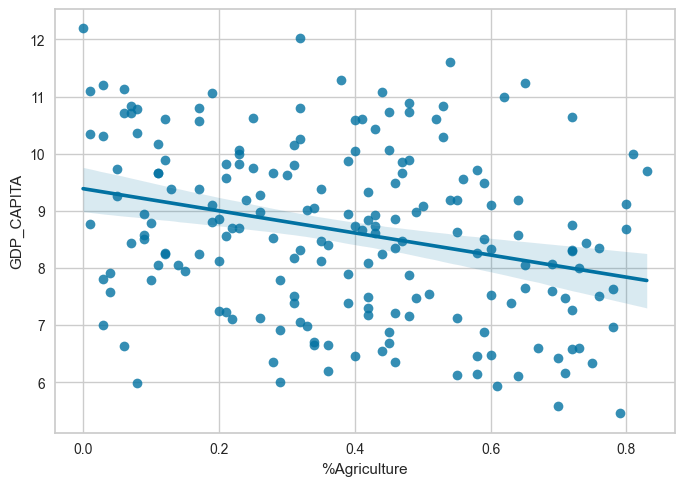

In [103]:
sns.regplot(data=df, x=X,y=y);

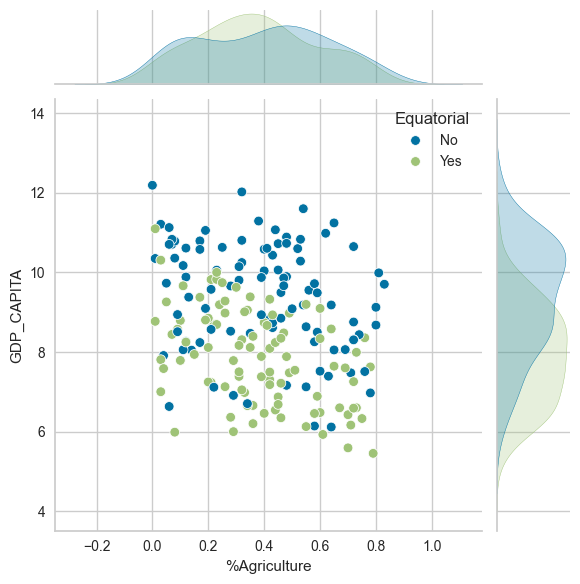

In [104]:
sns.jointplot(data=df, x=X, y=y, hue='Equatorial');

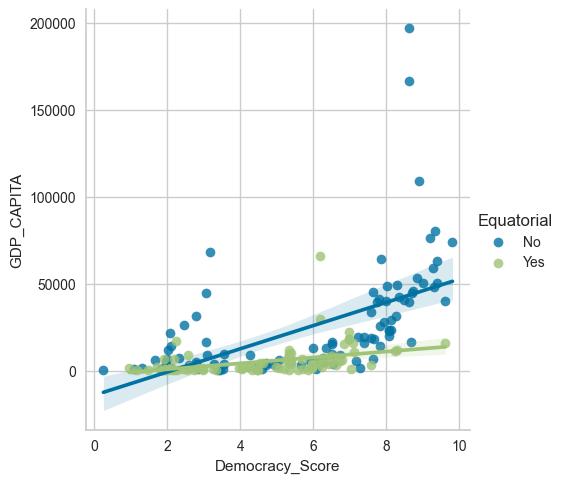

In [110]:

sns.lmplot(data=df, x='Democracy_Score', y='GDP_CAPITA',hue='Equatorial');


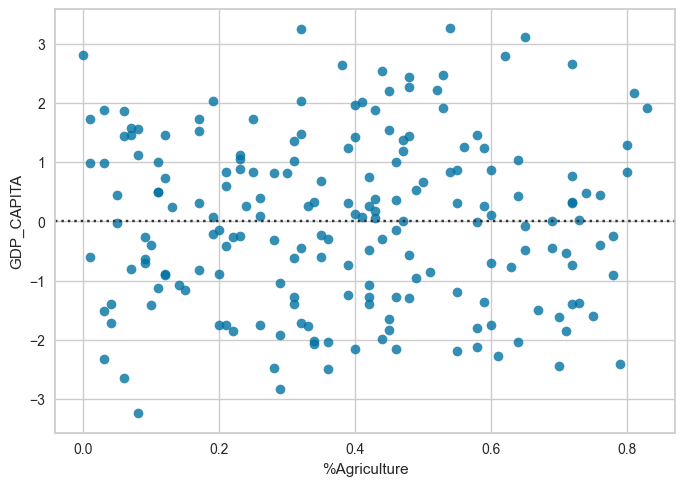

In [111]:
sns.residplot(data=df, x=X,y=y);

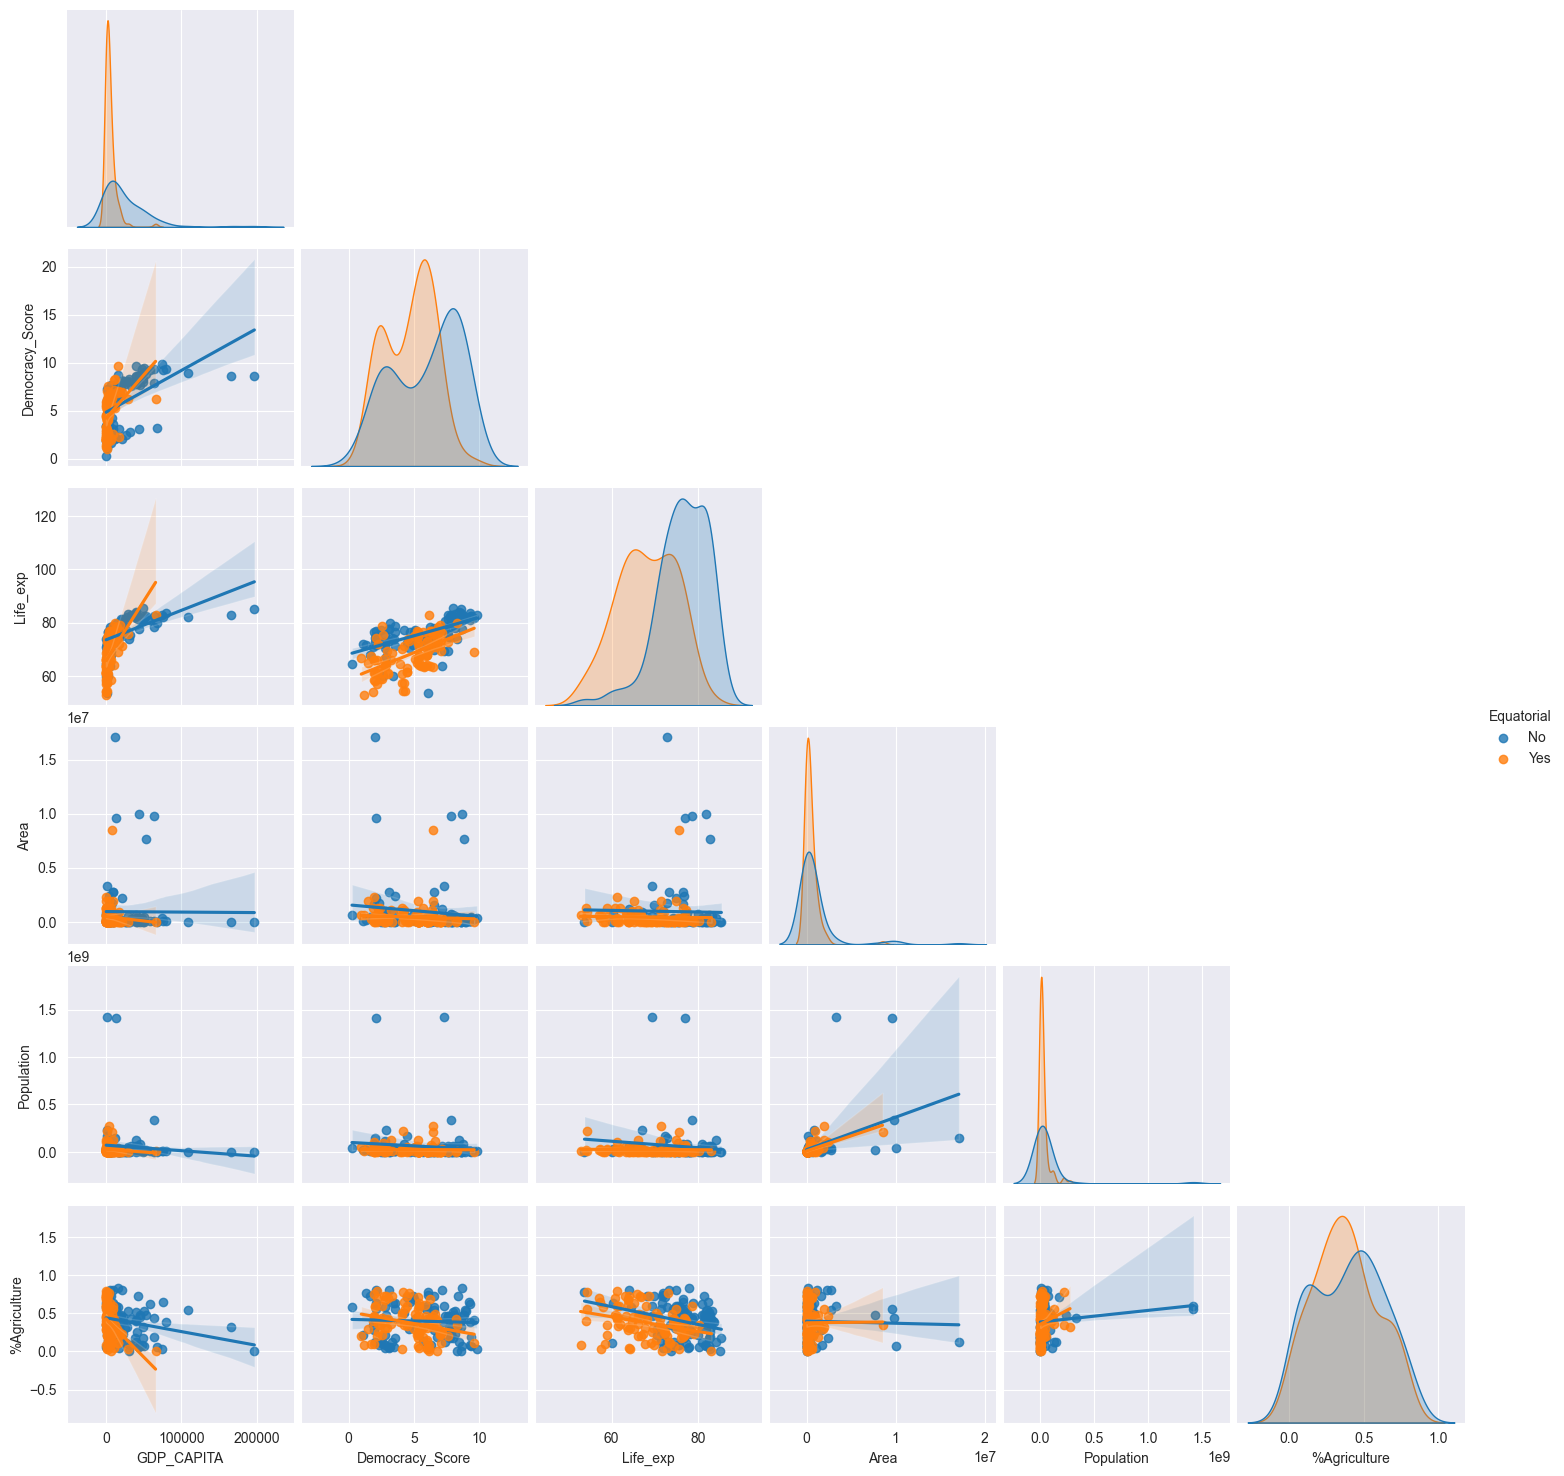

In [18]:
sns.pairplot(data=df_selected_cols, kind='reg',hue='Equatorial', corner=True);

In [19]:
X = sm.add_constant(X)

In [112]:
#statsmodels
ols=sm.OLS(y,X).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             GDP_CAPITA   R-squared (uncentered):                   0.691
Model:                            OLS   Adj. R-squared (uncentered):              0.689
Method:                 Least Squares   F-statistic:                              427.2
Date:                Fri, 24 Apr 2026   Prob (F-statistic):                    1.33e-50
Time:                        18:58:48   Log-Likelihood:                         -576.56
No. Observations:                 192   AIC:                                      1155.
Df Residuals:                     191   BIC:                                      1158.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
%Agriculture    16.4152      0.794     20.670      0.000      14.849      17.982
==============================================================================
Omnibus:                       10.717   Durbin-Watson:                   1.660
Prob(Omnibus):                  0.005   Jarque-Bera (JB):                4.707
Skew:                          -0.076   Prob(JB):                       0.0950
Kurtosis:                       2.248   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

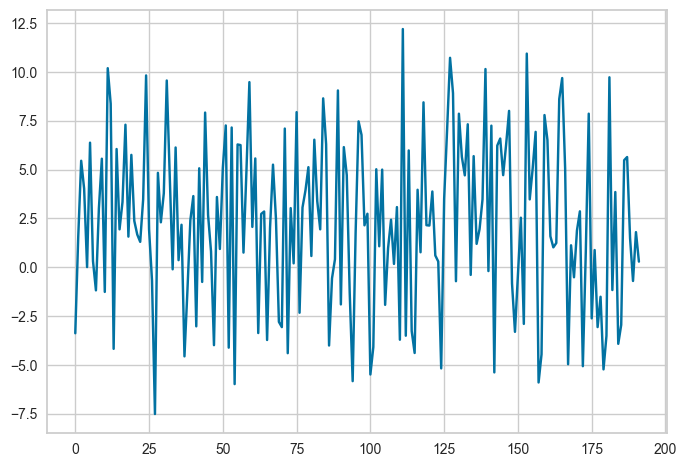

In [113]:
ols.resid.plot();

In [129]:
#sklearn
model_skl = LinearRegression().fit(X_test,y_test)
print(f"intercept: {model.intercept_}")
print(f"coeficient: {model.coef_}")
print(f"R2 {model.score(X_test,y_test)}")
      

intercept: -1.70793975988863
coeficient: [ 0.          0.14940828 -0.80574004 -0.27478309]
R2 0.7081036561732007


In [116]:
np.exp(model.predict([[1,82,0.03,0]]))

array([37025.66736096])

In [85]:
X_test=pd.get_dummies(df_selected_cols.drop(columns='GDP_CAPITA'), drop_first=True, dtype='int')
X_test=sm.add_constant(X_test)

y_test=np.log(df_selected_cols.GDP_CAPITA)

In [86]:
X_test

,const,Life_exp,%Agriculture,Equatorial_Yes
0,1.0,64.5,0.58,0
1,1.0,78.5,0.43,0
2,1.0,76.7,0.17,0
3,1.0,83.5,0.40,0
4,1.0,60.8,0.48,1
...,...,...,...,...
187,1.0,72.1,0.25,1
188,1.0,75.3,0.39,1
189,1.0,66.1,0.45,1
190,1.0,63.5,0.32,1


In [87]:
y_test

0       6.140811
1       8.613296
2       8.238976
3      10.584376
4       7.885751
         ...    
187     9.743523
188     7.888927
189     6.683023
190     7.049446
191     7.180626
Name: GDP_CAPITA, Length: 192, dtype: float64

In [131]:
model = sm.OLS(y_test, X_test).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP_CAPITA   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     152.0
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           4.99e-50
Time:                        19:47:47   Log-Likelihood:                -230.99
No. Observations:                 192   AIC:                             470.0
Df Residuals:                     188   BIC:                             483.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7079      0.791     -2.158      0.032      -3.269      -0.147
Life_exp           0.1494      0.010     15.284      0.000       0.130       0.169
%Agriculture      -0.8057      0.280     -2.880      0.004      -1.358      -0.254
Equatorial_Yes    -0.2748      0.144     -1.914      0.057      -0.558       0.008
==============================================================================
Omnibus:                        0.332   Durbin-Watson:                   2.119
Prob(Omnibus):                  0.847   Jarque-Bera (JB):                0.133
Skew:                          -0.043   Prob(JB):                        0.936
Kurtosis:                       3.097   Cond. No.                         997.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [90]:
import scipy.stats as stats

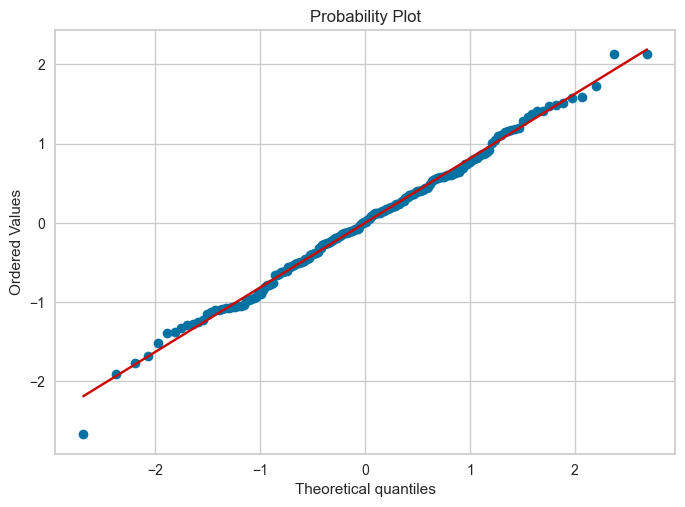

In [91]:
stats.probplot(model.resid, dist='norm',plot=plt);

In [97]:
np.exp(model.predict([1,82,0.03,0]))

array([37025.66736096])

In [122]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [124]:
variables = sm.OLS(y_test,X_test).exog

In [127]:
pd.Series([vif(variables, i)for i in range(variables.shape[1])],index=X_test.columns)

const             181.344285
Life_exp            1.570169
%Agriculture        1.100954
Equatorial_Yes      1.492454
dtype: float64

In [132]:
influence = model.get_influence()

In [135]:
influence.summary_frame()['cooks_d'].sort_values(ascending=False).head()

124    0.080796
131    0.074997
53     0.073667
94     0.059344
158    0.035711
Name: cooks_d, dtype: float64

In [137]:
df.loc[[124, 131]]

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Development_Status,Latitude,Longitude,Area,...,lon_pos,Equatorial,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category
124,Nigeria,Abuja,Federal Presidential Republic,Christianity,4.16,Hybrid Regime,Developing,9.0556,7.4914,923768,...,North,Yes,Yes,Africa,236.6,East Africa,No,485101,Lower-Middle,Low
131,Palestinian Authority,Ramallah,Semi-Presidential Republic,Islam,3.44,Authoritarian,Developing,31.8969,35.2017,6220,...,North,No,No,Asia,850.3,Western Asia/Middle East,No,645638,Low,Medium
